<a href="https://colab.research.google.com/github/nbustos05/coding-exercise-ml-basics/blob/main/coding_exerise_ml_run.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
## **QUESTION 1

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score

# Used to load the Ames housing dataset that will be used to train the model and run tests
## Data Source: Ames Housing Dataset from OpenML
## https://www.openml.org/search?type=data&status=active&id=42165

df = pd.read_csv("ames_house_prices.csv", na_values="?")

df = df[["GrLivArea", "Neighborhood", "SalePrice"]]

df = df.rename(columns={
    "GrLivArea": "square_footage",
    "Neighborhood": "location",
    "SalePrice": "price"
})
# remove rows that are missing values so that the model uses complete records
df = df.dropna(
    subset=["square_footage", "location", "price"]
)

print("Number of house records:", len(df))
print(df.head())

# Features and target
# x has the features that are used to predict/ y has the house predicts we're trying to predict
X = df[['square_footage', 'location']]
y = df['price']
# Preprocessing: One-hot encode the location column
preprocessor = ColumnTransformer(
transformers=[
('location', OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
), ['location'])
], remainder='passthrough')
# Create pipeline with preprocessing and model
model = Pipeline(steps=[
('preprocessor', preprocessor),
('regressor', LinearRegression())
])
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
random_state=42)
# Train model
model.fit(X_train, y_train)
test_predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, test_predictions)
r2 = r2_score(y_test, test_predictions)

print(f"\nMean Absolute Error: ${mae:,.2f}")
print(f"R-squared: {r2:.3f}")
# Make prediction for a new house: 2000 sq ft in Downtown
# The Ames dataset uses neighborhood names instead of Downtown / suburbs/ etc.
# OldTown is used as the location for this 2000 sq ft example
new_house = pd.DataFrame({'square_footage': [2000], 'location': ['OldTown']})
predicted_price = model.predict(new_house)

print(f"Predicted price for a 2000 sq ft house in OldTown: "
f"${predicted_price[0]:,.2f}"
)
# Display model coefficients
feature_names = (model.named_steps['preprocessor']
.named_transformers_['location']
.get_feature_names_out(['location'])).tolist() + \
['square_footage']

coefficients = model.named_steps['regressor'].coef_
print("\nModel Coefficients:")
for feature, coef in zip(feature_names, coefficients):
  print(f"{feature}: {coef:.2f}")
    ## The square_footage coefficient shows the estimated change in house price
## for each additional square foot, while keeping the neighborhood the same
## The location coefficients show how the predicted price changes by neighborhood
## compared with the reference neighborhood used by OneHotEncoder

Number of house records: 1460
   square_footage location   price
0            1710  CollgCr  208500
1            1262  Veenker  181500
2            1786  CollgCr  223500
3            1717  Crawfor  140000
4            2198  NoRidge  250000

Mean Absolute Error: $28,298.36
R-squared: 0.757
Predicted price for a 2000 sq ft house in OldTown: $166,393.08

Model Coefficients:
location_Blueste: -52493.23
location_BrDale: -67697.01
location_BrkSide: -50266.60
location_ClearCr: 384.74
location_CollgCr: 3576.11
location_Crawfor: -8854.29
location_Edwards: -56667.62
location_Gilbert: -13647.30
location_IDOTRR: -65165.18
location_MeadowV: -68899.62
location_Mitchel: -25562.94
location_NAmes: -36001.54
location_NPkVill: -33727.79
location_NWAmes: -25515.36
location_NoRidge: 54615.75
location_NridgHt: 81901.56
location_OldTown: -69047.67
location_SWISU: -78759.75
location_Sawyer: -37920.98
location_SawyerW: -20013.26
location_Somerst: 22401.94
location_StoneBr: 80334.48
location_Timber: 21141.82
lo

In [3]:
## **QUESTION 2

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
# Evaluation metrics added
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
## Data Source: Iranian Churn Dataset from UCI Machine Learning Repository
## https://archive.ics.uci.edu/dataset/563/iranian+churn+dataset

df = pd.read_csv("iranian_churn.csv")

df.columns = [" ".join(column.split()) for column in df.columns]

print("Number of customer records:", len(df))
print(df.head())
# Features and target
numerical_features = [
    "Age",
    "Subscription Length",
    "Seconds of Use",
    "Frequency of use",
    "Customer Value",
    "Call Failure",
    "Complains"
]
categorical_features = [
    "Tariff Plan",
    "Status"
]

features = numerical_features + categorical_features

df = df.dropna(subset=features + ["Churn"])
df["Churn"] = df["Churn"].astype(int)
df[categorical_features] = df[categorical_features].astype(str)

X = df[features]
y = df["Churn"]

# Preprocessing: Scale numerical features and one-hot encode categorical features
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)
# Create pipeline with preprocessing and model
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    (
        "classifier",
        LogisticRegression(
            random_state=42,
            max_iter=1000
        )
    )
])

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
random_state=42, stratify=y)
# Train model
model.fit(X_train, y_train)
test_predictions = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    test_predictions
)

precision = precision_score(
    y_test,
    test_predictions,
    zero_division=0
)

recall = recall_score(
    y_test,
    test_predictions,
    zero_division=0
)

f1 = f1_score(
    y_test,
    test_predictions,
    zero_division=0
)

conf_matrix = confusion_matrix(
    y_test,
    test_predictions
)

print(f"\nModel Accuracy: {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall: {recall:.2%}")
print(f"F1 Score: {f1:.2%}")

print("Confusion Matrix:")
print(conf_matrix)

# Predict churn probability for a new customer
new_customer = pd.DataFrame({
    "Age": [35],
    "Subscription Length": [18],
    "Seconds of Use": [1200],
    "Frequency of use": [20],
    "Customer Value": [60],
    "Call Failure": [8],
    "Complains": [1],
    "Tariff Plan": ["1"],
    "Status": ["2"]
})
churn_probability = model.predict_proba(new_customer)[0][1]
# Probability of churn
# (class 1)
# Classify based on threshold (0.5)
threshold = 0.5
churn_prediction = 1 if churn_probability >= threshold else 0
print(f"Churn Probability for new customer: {churn_probability:.2f}")
print(f"Churn Prediction (1 = churn, 0 = no churn): {churn_prediction}")

print(
    "A probability of 50% or higher means the customer "
    "is classified as being at risk of leaving."
)

print(
    "The business could contact at-risk customers with "
    "customer service, a plan review, or a retention offer."
)
# Display model coefficients
feature_names = (
    model.named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = (
    model.named_steps["classifier"]
    .coef_[0]
)

print("\nModel Coefficients:")
for feature, coef in zip(feature_names, coefficients):
    print(f"{feature}: {coef:.2f}")

Number of customer records: 3150
   Call Failure  Complains  Subscription Length  Charge Amount  \
0             8          0                   38              0   
1             0          0                   39              0   
2            10          0                   37              0   
3            10          0                   38              0   
4             3          0                   38              0   

   Seconds of Use  Frequency of use  Frequency of SMS  \
0            4370                71                 5   
1             318                 5                 7   
2            2453                60               359   
3            4198                66                 1   
4            2393                58                 2   

   Distinct Called Numbers  Age Group  Tariff Plan  Status  Age  \
0                       17          3            1       1   30   
1                        4          2            1       2   25   
2                       24

Number of customer records: 440
   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185
Inertia values:
K=1: 2640.00
K=2: 1956.12
K=3: 1608.43
K=4: 1317.84
K=5: 1058.77


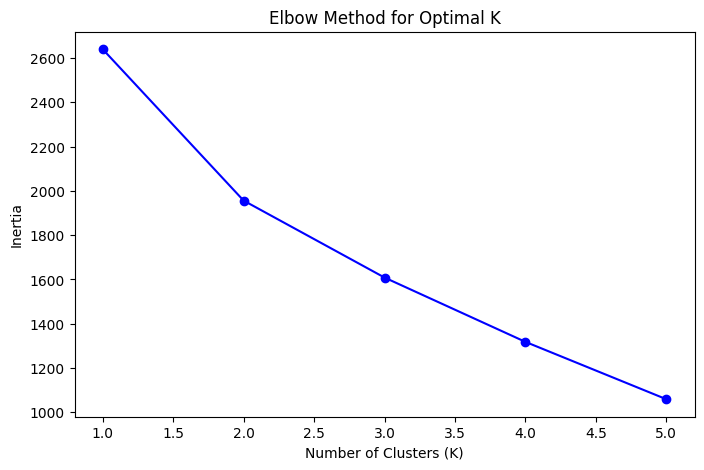

Cluster Characteristics:
            Fresh      Milk   Grocery    Frozen  Detergents_Paper  Delicassen
cluster                                                                      
0        10440.93  19386.42  28656.09   2190.24          13327.80     2374.20
1        12062.91   4115.10   5534.97   2940.68           1696.17     1299.11
2        34782.00  30367.00  16898.00  48701.50            755.50    26776.00

Cluster 0 Strategy:
Customers buy more grocery products. Offer grocery and household product bundles with volume discounts.

Cluster 1 Strategy:
Customers buy more fresh products. Offer fresh and frozen food packages for restaurants or food-service businesses.

Cluster 2 Strategy:
Customers buy more fresh products. Offer fresh and frozen food packages for restaurants or food-service businesses.


In [4]:
## **QUESTION 3

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

## Data Source: Wholesale Customers Dataset from UCI Machine Learning Repository
## https://archive.ics.uci.edu/dataset/292/wholesale+customers
df = pd.read_csv("wholesale_customers.csv")

print("Number of customer records:", len(df))
print(df.head())
# Preprocess data: Select numerical features and scale them
features = [
    "Fresh",
    "Milk",
    "Grocery",
    "Frozen",
    "Detergents_Paper",
    "Delicassen"
]

df = df.dropna(subset=features)

X = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Determine optimal number of clusters using elbow method

inertia = []
K = range(1, 6)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

print("Inertia values:")
for k, value in zip(K, inertia):
    print(f"K={k}: {value:.2f}")
# Plot elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.savefig('elbow_plot.png')
plt.show()
# Apply K-Means with optimal K (e.g., 3 based on elbow method)
## The inertia decreased a lot more through the first few clusters, but improvements were getting smaller over time after 3 clusters.
## 3 clusters was the random example, but after a bit of testing it was discovered to be the sweet spot.
##Three clusters created groups with different customer spending patterns.
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)
# Analyze clusters
cluster_summary = df.groupby('cluster')[features].mean().round(2)
print("Cluster Characteristics:")
print(cluster_summary)
# Example of targeted strategies
for cluster in range(optimal_k):
    print(f"\nCluster {cluster} Strategy:")

    if (
        cluster_summary.loc[cluster, "Fresh"]
        > cluster_summary.loc[cluster, "Grocery"]
    ):
        print(
            "Customers buy more fresh products. "
            "Offer fresh and frozen food packages for "
            "restaurants or food-service businesses."
        )
    else:
        print(
            "Customers buy more grocery products. "
            "Offer grocery and household product bundles "
            "with volume discounts."
        )

# Save cluster assignments to CSV
df.to_csv('customer_segments.csv', index=False)